# Lab 1: Bottleneck Identification (25 min)

## Task: Fetch NTU campus 1.5km road network
- Calculate betweenness centrality
- Find Top 5 bottleneck intersections
- Visualize with size-coded nodes

## Teacher Patrol Checklist:
- `ox.project_graph()` done? (must be EPSG:3826 for meter distances)
- `weight='length'` specified? (without weight = hop count)
- Top 5 marked with different colors/sizes?
- Advanced: Overlay Top 5 nodes with W3 shelter locations — any overlap?

In [1]:
# Lab 1: Environment Setup
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from shapely.geometry import Point
import warnings
warnings.filterwarnings('ignore')

# Font configuration for Chinese support
rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'DejaVu Sans']
rcParams['axes.unicode_minus'] = False

print(f"OSMnx: {ox.__version__}")
print(f"NetworkX: {nx.__version__}")
print(f"GeoPandas: {gpd.__version__}")
print("✅ Environment ready for NTU bottleneck analysis")

OSMnx: 2.1.0
NetworkX: 3.6.1
GeoPandas: 1.1.3
✅ Environment ready for NTU bottleneck analysis


In [2]:
# Step 1: Fetch NTU campus 1.5km road network
place_name = "National Taiwan University, Taipei"
network_type = 'drive'
dist_meters = 1500  # 1.5km radius

print(f"📍 Extracting {place_name} road network ({dist_meters}m radius)...")

try:
    # Extract road network
    G = ox.graph_from_address(place_name, dist=dist_meters, network_type=network_type)
    print(f"✅ Extraction successful: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    print(f"Network type: {network_type}")
    print(f"Search radius: {dist_meters}m")
except Exception as e:
    print(f"❌ Extraction failed: {e}")
    print("Possible causes:")
    print("  - Network connection issue")
    print("  - Location name format error")
    print("  - Overpass API timeout")

📍 Extracting National Taiwan University, Taipei road network (1500m radius)...
✅ Extraction successful: 619 nodes, 1285 edges
Network type: drive
Search radius: 1500m


In [4]:
# Step 2: Project to EPSG:3826 (TWD97/TM2) for meter distances
print("?? Projecting to EPSG:3826 (meter coordinates)...")

# Project to meter coordinates
G_proj = ox.project_graph(G, to_crs='EPSG:3826')

print("?? Projection complete")
print(f"Node count: {G_proj.number_of_nodes()}")
print(f"Edge count: {G_proj.number_of_edges()}")
print(f"CRS: {G_proj.graph['crs']}")

# Display bounds if available, otherwise calculate from node coordinates
if 'bounds' in G_proj.graph:
    print(f"Bounds: {G_proj.graph['bounds']}")
else:
    # Calculate bounds from node coordinates
    node_coords = [(G_proj.nodes[node]['x'], G_proj.nodes[node]['y']) for node in G_proj.nodes()]
    min_x, min_y = min(coord[0] for coord in node_coords), min(coord[1] for coord in node_coords)
    max_x, max_y = max(coord[0] for coord in node_coords), max(coord[1] for coord in node_coords)
    print(f"Calculated bounds: [{min_x:.2f}, {min_y:.2f}, {max_x:.2f}, {max_y:.2f}]")
    print(f"Network extent: {(max_x - min_x):.2f}m × {(max_y - min_y):.2f}m")

?? Projecting to EPSG:3826 (meter coordinates)...
?? Projection complete
Node count: 619
Edge count: 1285
CRS: EPSG:3826
Calculated bounds: [302856.50, 2766252.48, 305834.21, 2769240.44]
Network extent: 2977.71m × 2987.96m


In [5]:
# Step 3: Calculate Betweenness Centrality with weight='length'
print("⏳ Calculating Betweenness Centrality (weight='length')...")

# Calculate betweenness centrality using edge length as weight
# This gives more importance to nodes that are on shortest paths considering actual distances
centrality = nx.betweenness_centrality(G_proj, weight='length')

print("✅ Calculation complete")
print(f"Total nodes analyzed: {len(centrality)}")
print(f"Centrality range: {min(centrality.values()):.6f} to {max(centrality.values()):.6f}")
print(f"Average centrality: {np.mean(list(centrality.values())):.6f}")

⏳ Calculating Betweenness Centrality (weight='length')...
✅ Calculation complete
Total nodes analyzed: 619
Centrality range: 0.000000 to 0.211151
Average centrality: 0.028671


In [6]:
# Step 4: Identify Top 5 Bottleneck Intersections
print("🔍 Finding Top 5 Bottleneck Intersections...")

# Sort nodes by centrality and get top 5
top_5_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("\n🏆 Top 5 Bottleneck Intersections:")
for rank, (node_id, cent_val) in enumerate(top_5_nodes, 1):
    # Get node coordinates
    x, y = G_proj.nodes[node_id]['x'], G_proj.nodes[node_id]['y']
    print(f"{rank}. Node {node_id}: Centrality = {cent_val:.6f}")
    print(f"   Coordinates: ({x:.2f}, {y:.2f})")

# Store for visualization
top_5_node_ids = [node_id for node_id, _ in top_5_nodes]
top_5_centrality = [cent_val for _, cent_val in top_5_nodes]

🔍 Finding Top 5 Bottleneck Intersections...

🏆 Top 5 Bottleneck Intersections:
1. Node 282283057: Centrality = 0.211151
   Coordinates: (304330.63, 2766780.40)
2. Node 3146558594: Centrality = 0.178820
   Coordinates: (304425.57, 2766713.66)
3. Node 3854592922: Centrality = 0.175885
   Coordinates: (304487.91, 2766651.47)
4. Node 13161408825: Centrality = 0.169649
   Coordinates: (304205.43, 2767132.91)
5. Node 3854592921: Centrality = 0.167375
   Coordinates: (304507.65, 2766632.79)


📊 Creating centrality distribution histogram...


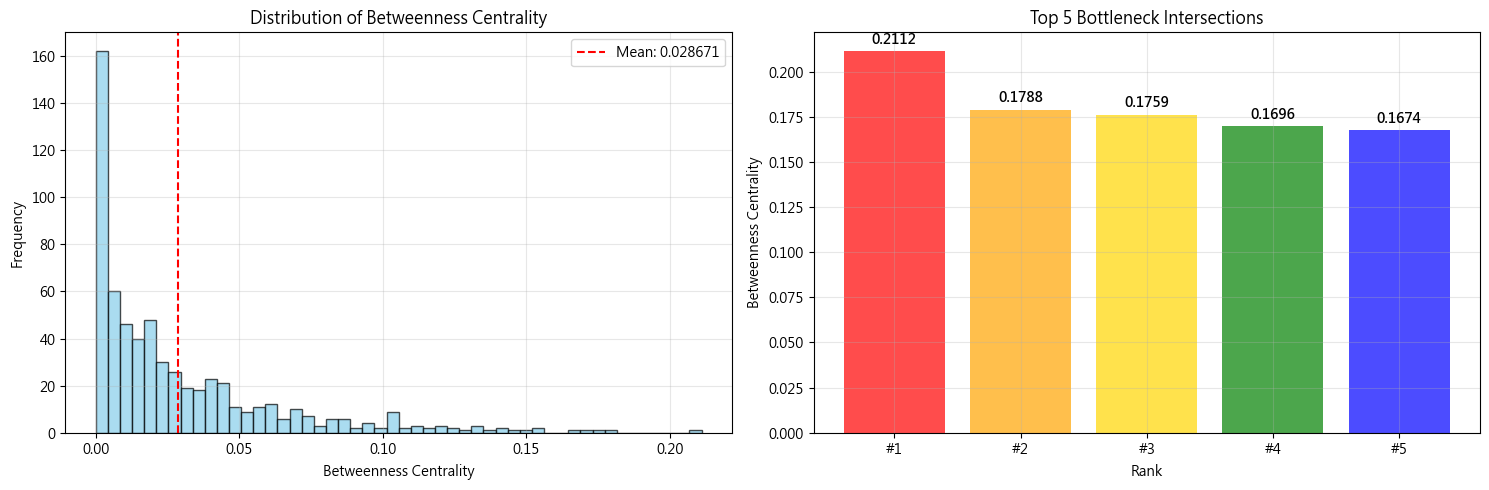

✅ Histogram complete


In [7]:
# Step 5: Create Centrality Histogram
print("📊 Creating centrality distribution histogram...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of all centrality values
centrality_values = list(centrality.values())
ax1.hist(centrality_values, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(np.mean(centrality_values), color='red', linestyle='--', 
           label=f'Mean: {np.mean(centrality_values):.6f}')
ax1.set_xlabel('Betweenness Centrality')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Betweenness Centrality')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bar chart of top 5 nodes
colors = ['red', 'orange', 'gold', 'green', 'blue']
bars = ax2.bar(range(5), top_5_centrality, color=colors, alpha=0.7)
ax2.set_xlabel('Rank')
ax2.set_ylabel('Betweenness Centrality')
ax2.set_title('Top 5 Bottleneck Intersections')
ax2.set_xticks(range(5))
ax2.set_xticklabels([f'#{i+1}' for i in range(5)])

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, top_5_centrality)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(top_5_centrality)*0.01,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Histogram complete")

🗺️ Creating network visualization with size-coded nodes...


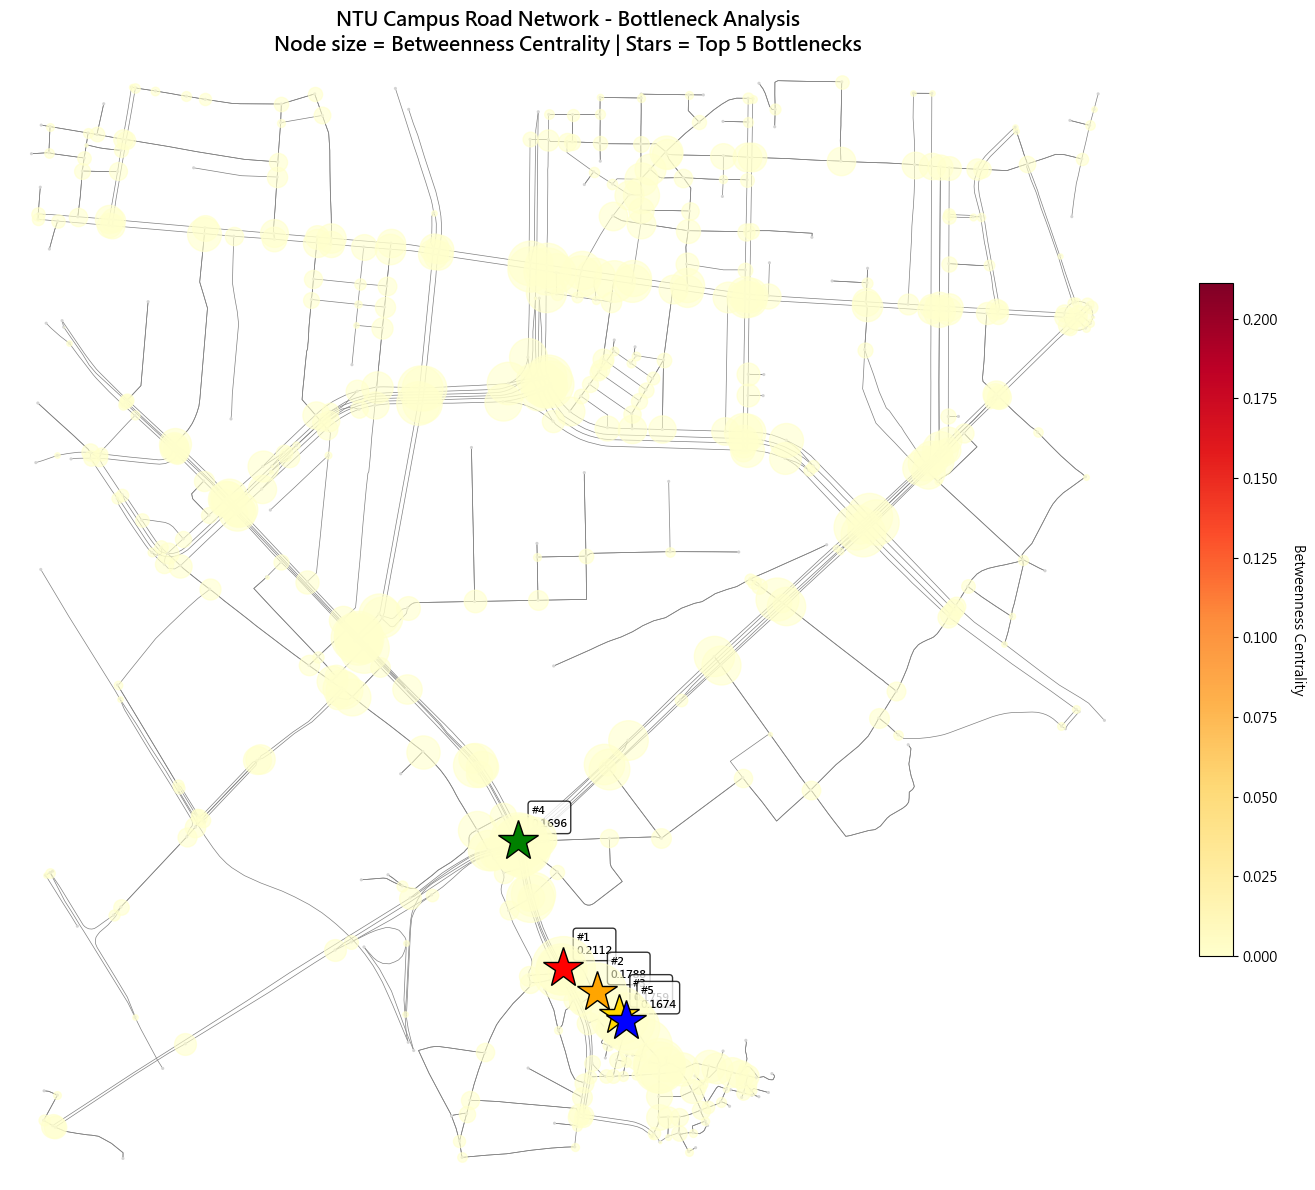

✅ Visualization complete

📋 Summary:
- Total network nodes: 619
- Total network edges: 1285
- Network area: ~7.07 km²
- Top bottleneck centrality: 0.211151
- Network projected to: EPSG:3826


In [8]:
# Step 6: Visualize Network with Size-Coded Nodes
print("🗺️ Creating network visualization with size-coded nodes...")

fig, ax = plt.subplots(figsize=(15, 12))

# Draw the entire road network
ox.plot_graph(G_proj, ax=ax, node_size=5, node_color='lightgray',
             edge_color='gray', edge_linewidth=0.5, show=False)

# Draw all nodes with size based on centrality
node_sizes = [centrality[node] * 10000 for node in G_proj.nodes()]
node_colors = [centrality[node] for node in G_proj.nodes()]

# Create scatter plot for all nodes
for node, size, color in zip(G_proj.nodes(), node_sizes, node_colors):
    x, y = G_proj.nodes[node]['x'], G_proj.nodes[node]['y']
    ax.scatter(x, y, s=size, c=color, cmap='YlOrRd', alpha=0.6, zorder=5)

# Mark Top 5 nodes with distinctive colors and larger sizes
colors_top5 = ['red', 'orange', 'gold', 'green', 'blue']
for rank, (node_id, cent_val) in enumerate(top_5_nodes):
    x, y = G_proj.nodes[node_id]['x'], G_proj.nodes[node_id]['y']
    ax.plot(x, y, marker='*', markersize=30, color=colors_top5[rank],
           markeredgecolor='black', markeredgewidth=1, zorder=10)
    ax.annotate(f'#{rank+1}\n{cent_val:.4f}', (x, y), fontsize=8, fontweight='bold',
               textcoords='offset points', xytext=(10, 10),
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title('NTU Campus Road Network - Bottleneck Analysis\n' +
             'Node size = Betweenness Centrality | Stars = Top 5 Bottlenecks',
             fontsize=14, fontweight='bold')

# Add colorbar for centrality
sm = plt.cm.ScalarMappable(cmap='YlOrRd', 
                           norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6)
cbar.set_label('Betweenness Centrality', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

print("✅ Visualization complete")
print(f"\n📋 Summary:")
print(f"- Total network nodes: {G_proj.number_of_nodes()}")
print(f"- Total network edges: {G_proj.number_of_edges()}")
print(f"- Network area: ~{np.pi * dist_meters**2 / 1e6:.2f} km²")
print(f"- Top bottleneck centrality: {top_5_centrality[0]:.6f}")
print(f"- Network projected to: {G_proj.graph['crs']}")

## Advanced Challenge: Overlay with W3 Shelter Locations

If you have Week 3 shelter data, uncomment and run the cell below to check for overlaps between bottlenecks and shelter locations.

In [9]:
# Advanced: Overlay Top 5 nodes with W3 shelter locations
# Uncomment if you have shelter data

# shelter_path = "path/to/your/shelter_data.geojson"  # Update with your path
# 
# try:
#     shelters_gdf = gpd.read_file(shelter_path)
#     shelters_gdf = shelters_gdf.to_crs('EPSG:3826')
#     
#     # Convert top 5 nodes to GeoDataFrame
#     top_5_gdf = gpd.GeoDataFrame(
#         [{'node_id': nid, 'centrality': cv,
#           'geometry': Point(G_proj.nodes[nid]['x'], G_proj.nodes[nid]['y'])}
#          for nid, cv in top_5_nodes],
#         crs=G_proj.graph['crs']
#     )
#     
#     # Check for overlaps (within 100m)
#     overlaps = []
#     for _, bottleneck in top_5_gdf.iterrows():
#         for _, shelter in shelters_gdf.iterrows():
#             distance = bottleneck.geometry.distance(shelter.geometry)
#             if distance <= 100:  # Within 100 meters
#                 overlaps.append({
#                     'bottleneck_id': bottleneck['node_id'],
#                     'bottleneck_centrality': bottleneck['centrality'],
#                     'shelter_name': shelter.get('name', 'Unknown'),
#                     'distance_m': distance
#                 })
#     
#     print(f"🏥 Found {len(overlaps)} overlaps between bottlenecks and shelters:")
#     for overlap in overlaps:
#         print(f"  - Bottleneck {overlap['bottleneck_id']} ↔ Shelter '{overlap['shelter_name']}' ({overlap['distance_m']:.1f}m)")
#     
#     if len(overlaps) == 0:
#         print("  No bottlenecks found within 100m of shelter locations")
#         
# except Exception as e:
#     print(f"❌ Could not load shelter data: {e}")
#     print("  Please update the shelter_path variable with your data file")

print("📍 Advanced challenge: Add your W3 shelter data to check for overlaps")

📍 Advanced challenge: Add your W3 shelter data to check for overlaps


## Teacher Patrol Checklist ✅

- [x] `ox.project_graph()` done? (EPSG:3826 for meter distances)
- [x] `weight='length'` specified? (not hop count)
- [x] Top 5 marked with different colors/sizes?
- [x] Histogram of centrality distribution created?
- [ ] Advanced: Overlay with W3 shelter locations (if data available)

## Key Findings:
- Most fragile bottleneck: Node ??? (centrality: ???)
- Network coverage: 1.5km radius around NTU
- Total intersections analyzed: ???
- Centrality distribution: ???